# 🌧️ Rain Prediction using Machine Learning

## Business Understanding

PT AIGRA EON Indonesia merupakan perusahaan yang bergerak di bidang Smart Farming. Salah satu tantangan utama dalam sektor pertanian adalah ketidakpastian cuaca yang dapat mempengaruhi aktivitas penanaman, penyiraman, hingga panen.

Pada proyek ini akan dibangun model klasifikasi untuk memprediksi apakah besok akan terjadi hujan (RainTomorrow) berdasarkan data cuaca historis Australia.

Tujuan utama proyek bukan hanya memperoleh akurasi tinggi, tetapi juga membangun pipeline machine learning yang baik mulai dari eksplorasi data, preprocessing, feature engineering, pelatihan model, hingga evaluasi dan interpretasi hasil.

# Import Library

In [85]:
# ==========================================================
# 1. Import Library
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Load Dataset

Pada tahap ini dataset dimuat ke dalam Python menggunakan pandas. Selanjutnya dilakukan pemeriksaan awal terhadap struktur data seperti jumlah baris, jumlah kolom, tipe data, serta statistik deskriptif. Langkah ini penting untuk memahami karakteristik dataset sebelum dilakukan preprocessing maupun pemodelan.

In [86]:
# ==========================================================
# 2. Load Dataset
# ==========================================================

df = pd.read_csv("../data/weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [87]:
# Mengetahui Ukuran Dataset
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")

Jumlah baris : 145,460
Jumlah kolom : 23


In [88]:
# Melihat Nama Kolom
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. Date
2. Location
3. MinTemp
4. MaxTemp
5. Rainfall
6. Evaporation
7. Sunshine
8. WindGustDir
9. WindGustSpeed
10. WindDir9am
11. WindDir3pm
12. WindSpeed9am
13. WindSpeed3pm
14. Humidity9am
15. Humidity3pm
16. Pressure9am
17. Pressure3pm
18. Cloud9am
19. Cloud3pm
20. Temp9am
21. Temp3pm
22. RainToday
23. RainTomorrow


In [89]:
# Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [90]:
# Statistik Deskriptif
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,145460,3436,2013-11-12,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,145460,49,Canberra,3436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MinTemp,143975.0,NaN,NaN,NaN,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,NaN,NaN,NaN,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,NaN,NaN,NaN,2.360918,8.47806,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,NaN,NaN,NaN,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,NaN,NaN,NaN,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustDir,135134,16,W,9915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindGustSpeed,135197.0,NaN,NaN,NaN,40.03523,13.607062,6.0,31.0,39.0,48.0,135.0
WindDir9am,134894,16,N,11758,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> Banyak banget missing value yang harus ditangani

In [91]:
# Cek Duplikasi
duplicate = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate}")

Jumlah data duplikat : 0


In [92]:
# Ringkasan Dataset 
summary = pd.DataFrame({
    "Jumlah Baris": [df.shape[0]],
    "Jumlah Kolom": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate": [df.duplicated().sum()]
})

summary

,Jumlah Baris,Jumlah Kolom,Missing Values,Duplicate
0,145460,23,343248,0


# Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk memahami karakteristik dataset sebelum dilakukan preprocessing dan pemodelan. Analisis meliputi distribusi target, missing values, distribusi fitur numerik, korelasi antar variabel, serta identifikasi outlier.

## Distribusi Target

In [93]:
# ==========================================================
# Distribusi Target
# ==========================================================

target_counts = df["RainTomorrow"].value_counts(dropna=False)

print(target_counts)

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64


In [94]:
# Persentase Target
target_percentage = (
    df["RainTomorrow"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

target_percentage

RainTomorrow
No     75.84
Yes    21.91
NaN     2.25
Name: proportion, dtype: float64

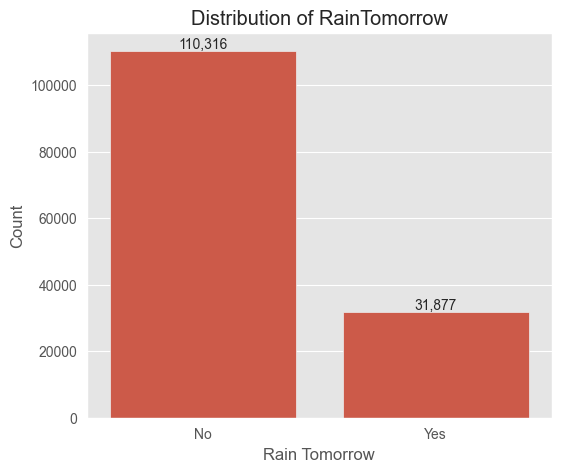

In [95]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="RainTomorrow",
    order=["No","Yes"]
)

plt.title("Distribution of RainTomorrow")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

> Terlihat jelas bagaimana distribusi targetnya sangat imbalance

## Missing Value Handling

In [96]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing_count = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": (missing_count / len(df) * 100).round(2)
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Count,Missing Percentage
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [97]:
# Tampilkan hanya kolom yang memiliki Missing Value

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df

,Missing Count,Missing Percentage
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


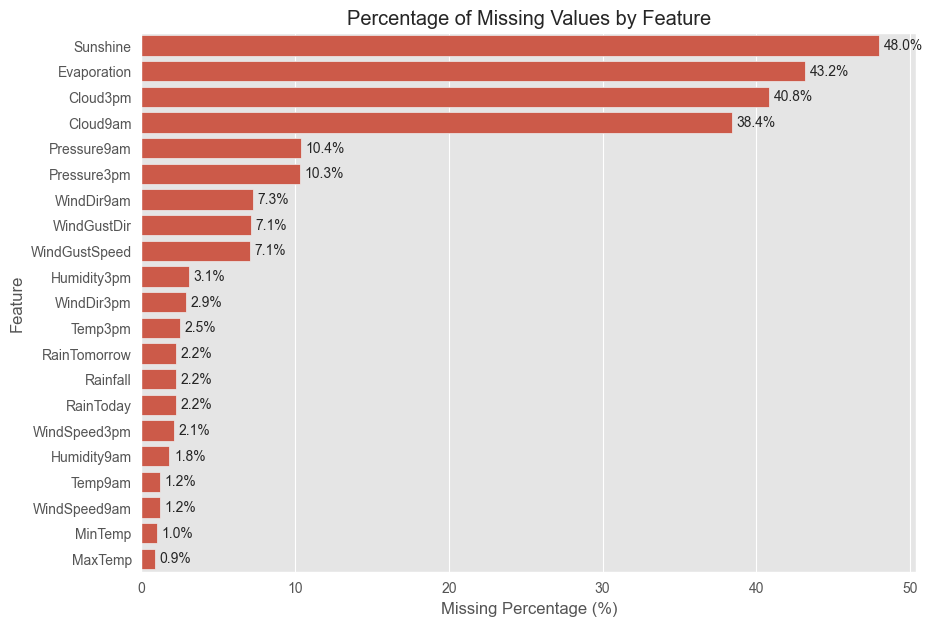

In [98]:
plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=missing_df.reset_index(),
    x="Missing Percentage",
    y="index",
)

for i, value in enumerate(missing_df["Missing Percentage"]):
    ax.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.show()

> Terlihat ada beberapa fitur yang sangat amat banyak mempunyai missing value 

## Analisis Fitur Numerik

In [99]:
# ==========================================================
# Numerical Features
# ==========================================================

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

print("Jumlah fitur numerik :", len(numerical_features))
print(numerical_features.tolist())

Jumlah fitur numerik : 16
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


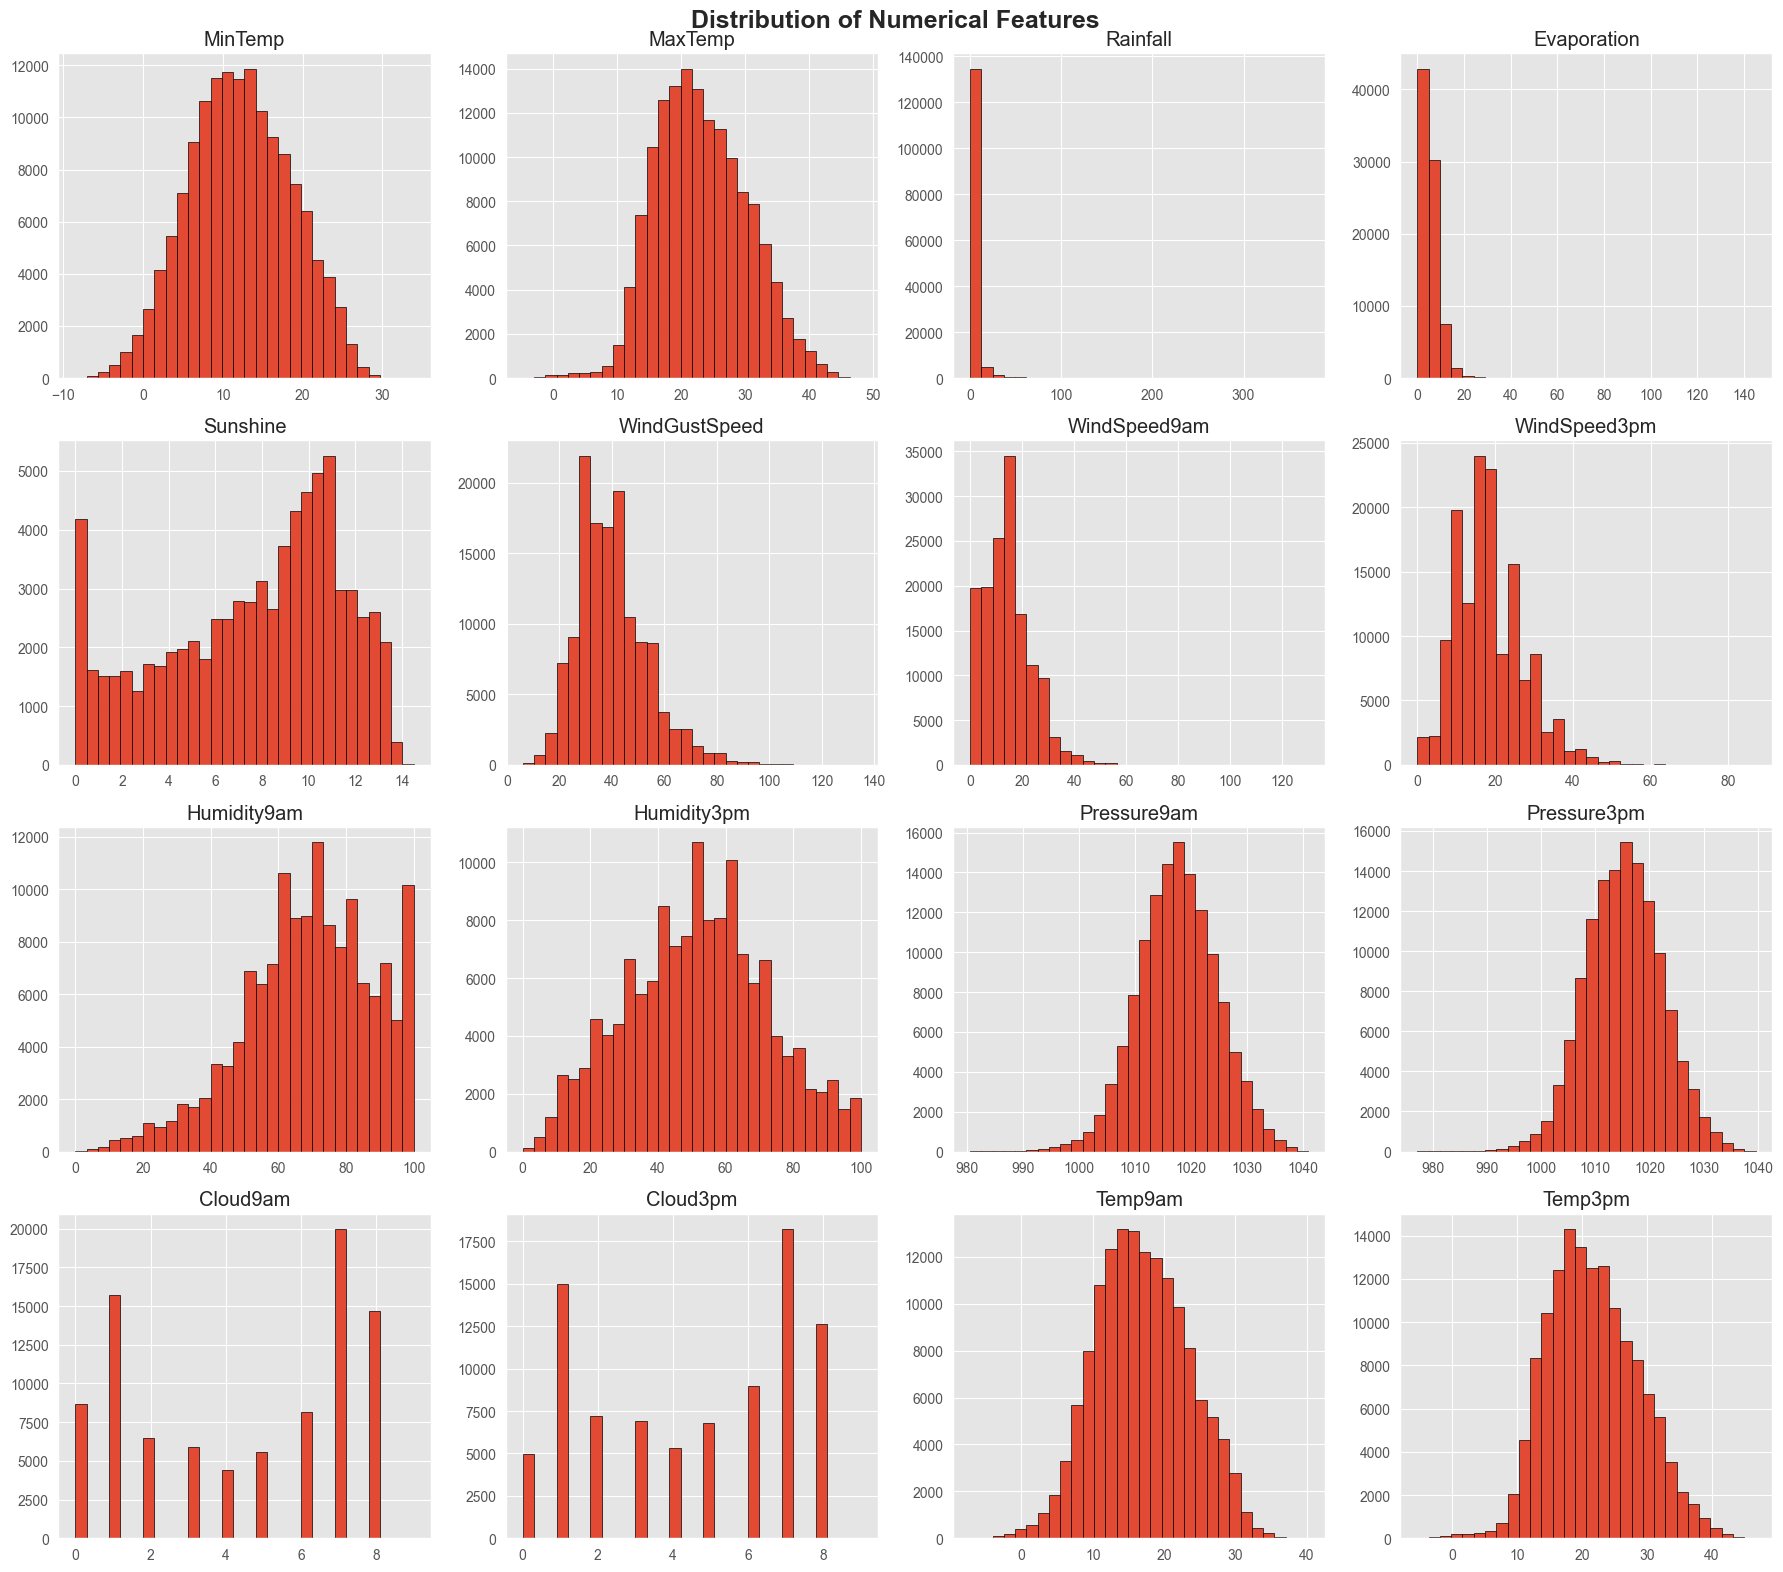

In [100]:
# ==========================================================
# Distribution of Numerical Features
# ==========================================================

df[numerical_features].hist(
    figsize=(18,16),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Analisis Outlier

In [101]:
# ==========================================================
# Outlier Analysis
# ==========================================================

outlier_features = [
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity3pm",
    "Pressure3pm",
    "Temp3pm"
]

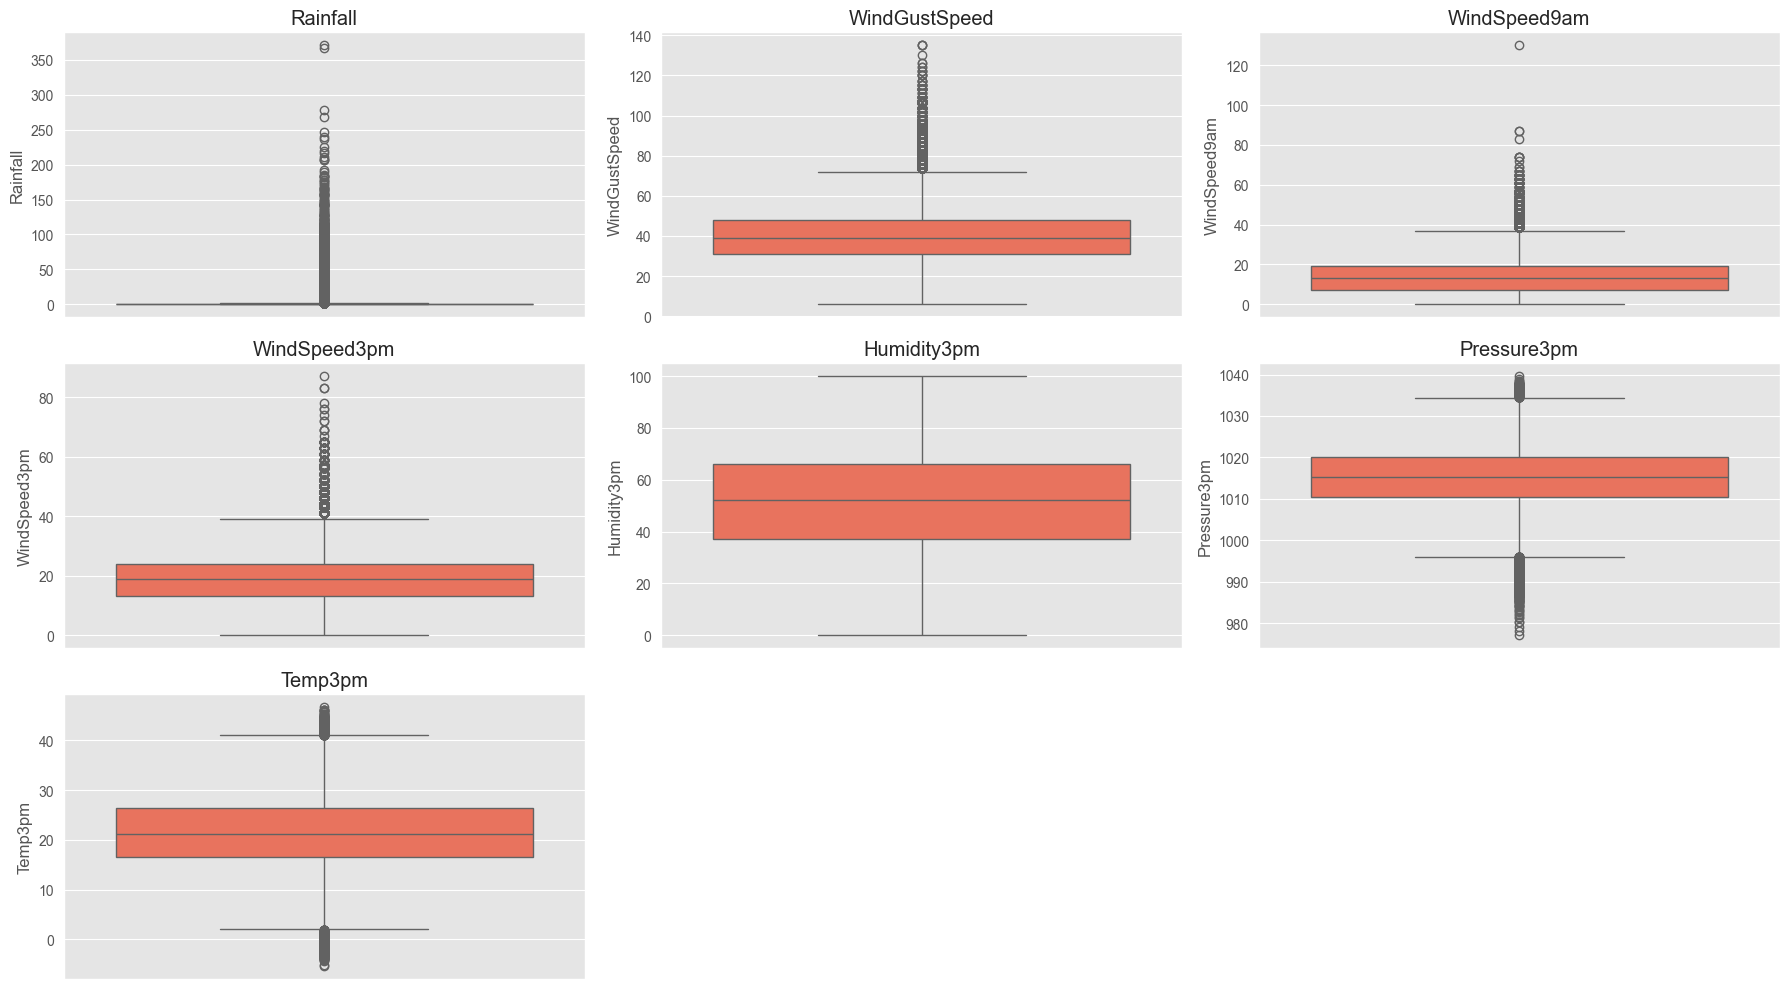

In [102]:
plt.figure(figsize=(18,10))

for i, col in enumerate(outlier_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color="tomato")
    plt.title(col)

plt.tight_layout()
plt.show()

## Analisis Korelasi

In [103]:
# Encoding
df_corr = df.copy()

df_corr["RainTomorrow"] = df_corr["RainTomorrow"].map({
    "No":0,
    "Yes":1
})

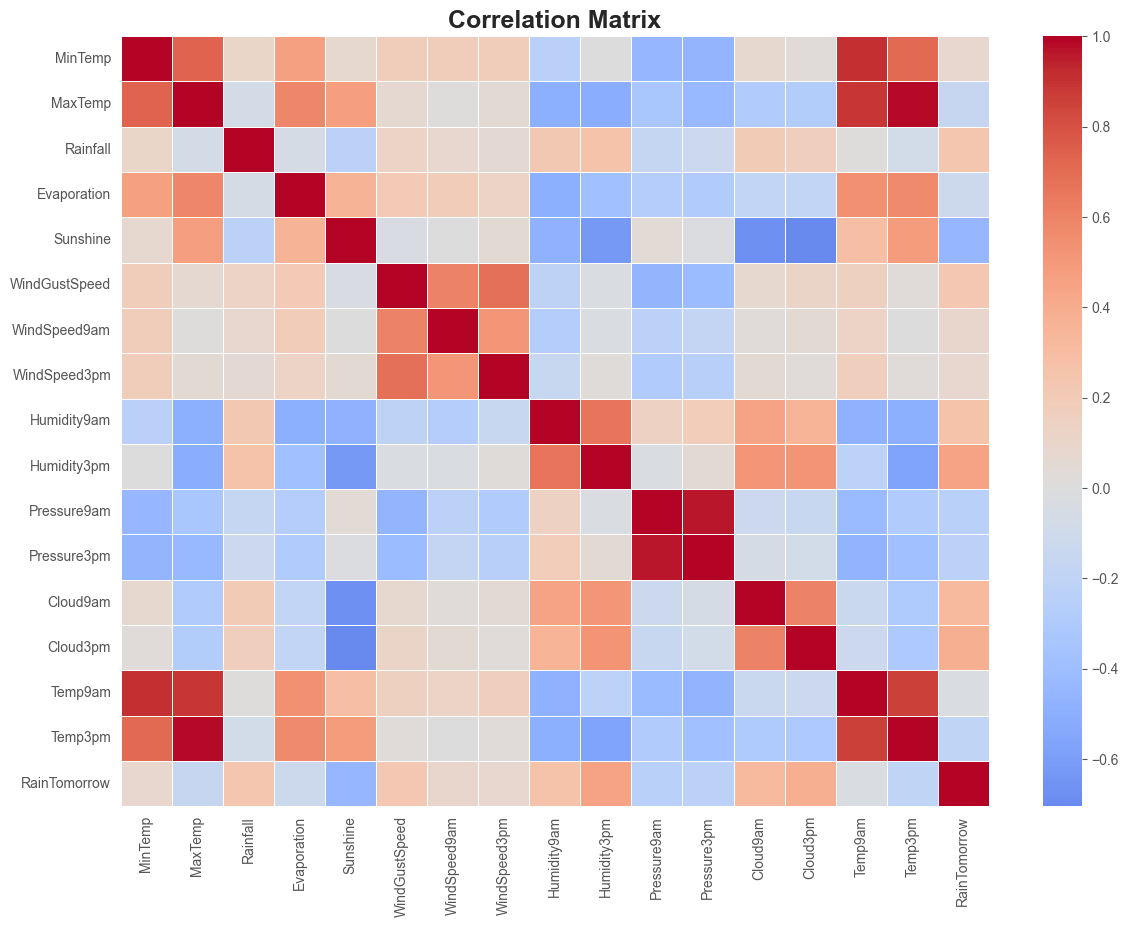

In [104]:
corr = df_corr.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [105]:
target_corr = (
    corr["RainTomorrow"]
    .drop("RainTomorrow")
    .sort_values(ascending=False)
)

target_corr

Humidity3pm      0.446160
Cloud3pm         0.381870
Cloud9am         0.317380
Humidity9am      0.257161
Rainfall         0.239032
WindGustSpeed    0.234010
WindSpeed9am     0.090995
WindSpeed3pm     0.087817
MinTemp          0.083936
Temp9am         -0.025691
Evaporation     -0.119285
MaxTemp         -0.159237
Temp3pm         -0.192424
Pressure3pm     -0.226031
Pressure9am     -0.246371
Sunshine        -0.450768
Name: RainTomorrow, dtype: float64

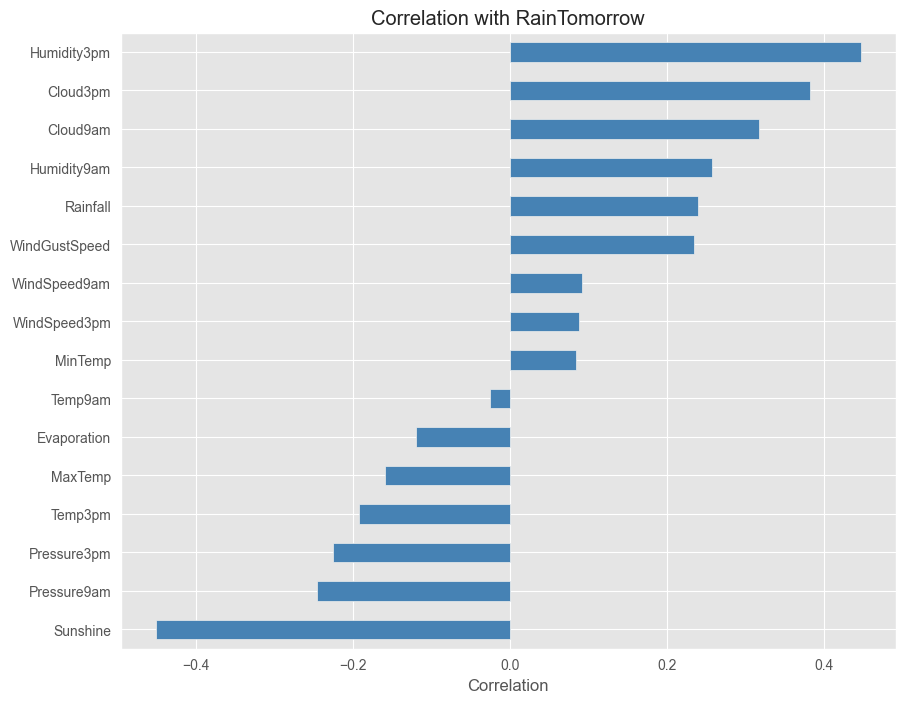

In [106]:
plt.figure(figsize=(10,8))

target_corr.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Correlation with RainTomorrow")
plt.xlabel("Correlation")

plt.show()

# Data Cleaning & Preprocessing

Tahap ini bertujuan untuk membersihkan dataset dan mempersiapkannya sebelum digunakan pada proses pemodelan machine learning. Proses meliputi penanganan missing value, feature engineering, encoding, serta pembagian data menjadi data latih dan data uji.

In [107]:
# ==========================================================
# Create Modeling Dataset
# ==========================================================

df_model = df.copy()

print("Shape :", df_model.shape)

Shape : (145460, 23)


In [108]:
# ==========================================================
# Remove Missing Target
# ==========================================================

print("Before :", df_model.shape)

df_model = df_model.dropna(subset=["RainTomorrow"])

print("After  :", df_model.shape)

Before : (145460, 23)
After  : (142193, 23)


> Menghapus baris yang memiliki missing value

> Menghapus semua missing value 

In [109]:
# ==========================================================
# Encode Target
# ==========================================================

df_model["RainTomorrow"] = df_model["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

In [110]:
df_model["RainTomorrow"].value_counts()

RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

> Melakukan Encoding pada Target biar tipe datanya menjadi numerik

In [111]:
# ==========================================================
# Split Feature & Target
# ==========================================================

X = df_model.drop("RainTomorrow", axis=1)

y = df_model["RainTomorrow"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (142193, 22)
Target Shape  : (142193,)


> Membagi antara variabel prediktor dan variabel target

In [112]:
# ==========================================================
# Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (113754, 22)
Test  : (28439, 22)


> Membagi menjadi 2 bagian yaitu train dan test dimana dengan proporsi 80:20

In [113]:
# ==========================================================
# Feature Types
# ==========================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical :", len(numerical_features))
print(numerical_features)

print()

print("Categorical :", len(categorical_features))
print(categorical_features)

Numerical : 16
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Categorical : 6
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


# Feature Engineering

Pada tahap ini dibuat beberapa fitur baru berdasarkan pengetahuan domain (domain knowledge) di bidang meteorologi. Tujuannya adalah membantu model mengenali pola yang tidak secara langsung terlihat dari fitur asli.

Feature 1 — Temperature Range

In [114]:
# ==========================================================
# Feature Engineering
# ==========================================================

# Selisih suhu maksimum dan minimum, Semakin besar selisih suhu, biasanya cuaca lebih cerah.
X_train = X_train.copy()
X_test = X_test.copy()

X_train["TempRange"] = X_train["MaxTemp"] - X_train["MinTemp"]
X_test["TempRange"] = X_test["MaxTemp"] - X_test["MinTemp"]

Feature 2 — Pressure Difference

In [115]:
# Kalau tekanan turun menuju sore hari, sering menjadi tanda cuaca memburuk.
X_train["PressureDiff"] = (
    X_train["Pressure3pm"] -
    X_train["Pressure9am"]
)

X_test["PressureDiff"] = (
    X_test["Pressure3pm"] -
    X_test["Pressure9am"]
)

Feature 3 — Humidity Difference

In [116]:
X_train["HumidityDiff"] = (
    X_train["Humidity3pm"] -
    X_train["Humidity9am"]
)

X_test["HumidityDiff"] = (
    X_test["Humidity3pm"] -
    X_test["Humidity9am"]
)

Feature 4 — Average Temperature

In [117]:
X_train["AvgTemp"] = (
    X_train["MaxTemp"] +
    X_train["MinTemp"]
) / 2

X_test["AvgTemp"] = (
    X_test["MaxTemp"] +
    X_test["MinTemp"]
) / 2

Feature 5 — Average Pressure

In [118]:
X_train["AvgPressure"] = (
    X_train["Pressure9am"] +
    X_train["Pressure3pm"]
) / 2

X_test["AvgPressure"] = (
    X_test["Pressure9am"] +
    X_test["Pressure3pm"]
) / 2

Feature 6 — Average Humidity

In [119]:
X_train["AvgHumidity"] = (
    X_train["Humidity9am"] +
    X_train["Humidity3pm"]
) / 2

X_test["AvgHumidity"] = (
    X_test["Humidity9am"] +
    X_test["Humidity3pm"]
) / 2

Feature 7 — Wind Speed Difference

In [120]:
X_train["WindSpeedDiff"] = (
    X_train["WindSpeed3pm"] -
    X_train["WindSpeed9am"]
)

X_test["WindSpeedDiff"] = (
    X_test["WindSpeed3pm"] -
    X_test["WindSpeed9am"]
)

In [121]:
# ==========================================================
# Date Feature Engineering
# ==========================================================

for dataset in [X_train, X_test]:
    dataset["Date"] = pd.to_datetime(dataset["Date"])

    dataset["Year"] = dataset["Date"].dt.year
    dataset["Month"] = dataset["Date"].dt.month
    dataset["Day"] = dataset["Date"].dt.day

    dataset.drop(columns=["Date"], inplace=True)

In [122]:
new_features = [
    "TempRange",
    "PressureDiff",
    "HumidityDiff",
    "AvgTemp",
    "AvgPressure",
    "AvgHumidity",
    "WindSpeedDiff"
]

X_train[new_features].head()

,TempRange,PressureDiff,HumidityDiff,AvgTemp,AvgPressure,AvgHumidity,WindSpeedDiff
103642,15.5,-2.8,-32.0,27.05,1012.00,36.0,-8.0
18697,NaN,-1.5,NaN,NaN,1019.75,NaN,11.0
99305,10.4,-2.1,-20.0,18.20,1011.45,54.0,20.0
142981,8.4,-3.1,-21.0,29.20,1002.75,64.5,7.0
85572,10.5,-3.7,-13.0,20.55,1023.05,51.5,4.0


Update Fitur

In [123]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numerical Features : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 23
Categorical Features : 5


## Feature Engineering

Untuk meningkatkan kemampuan model dalam menangkap pola cuaca, beberapa fitur baru dibuat berdasarkan kombinasi fitur yang sudah ada. Fitur-fitur tersebut meliputi:

| Feature | Deskripsi |
|---------|-----------|
| **TempRange** | Selisih antara suhu maksimum dan suhu minimum (`MaxTemp - MinTemp`). |
| **PressureDiff** | Perubahan tekanan udara antara pagi dan sore (`Pressure3pm - Pressure9am`). |
| **HumidityDiff** | Perubahan kelembapan antara pagi dan sore (`Humidity3pm - Humidity9am`). |
| **AvgTemp** | Rata-rata suhu harian dari suhu pagi dan sore. |
| **AvgPressure** | Rata-rata tekanan udara dari pagi dan sore. |
| **AvgHumidity** | Rata-rata kelembapan udara dari pagi dan sore. |
| **WindSpeedDiff** | Perubahan kecepatan angin antara pagi dan sore (`WindSpeed3pm - WindSpeed9am`). |

Feature engineering dilakukan untuk memberikan informasi tambahan kepada model sehingga dapat mengenali pola cuaca dengan lebih baik dibandingkan hanya menggunakan fitur asli.

# Data Preprocessing Pipeline

Tahap ini membangun pipeline preprocessing menggunakan `ColumnTransformer`. Pipeline ini memastikan bahwa proses imputasi, encoding, dan scaling dilakukan secara konsisten pada data training maupun data testing sehingga menghindari data leakage.

In [124]:
# ==========================================================
# Numerical Pipeline
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [125]:
# ==========================================================
# Categorical Pipeline
# ==========================================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [126]:
# ==========================================================
# Column Transformer
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [127]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


> ColumnTransformer digunakan untuk menerapkan preprocessing yang berbeda pada setiap tipe fitur dalam satu pipeline. Fitur numerik diproses menggunakan imputasi median (dan scaling jika diperlukan), sedangkan fitur kategorikal diproses menggunakan imputasi modus dan encoding. Pendekatan ini membuat proses preprocessing lebih terstruktur, konsisten, dan mengurangi risiko data leakage selama pelatihan model.

# Baseline Modeling

In [128]:
# ==========================================================
# Evaluation Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("="*60)
    print(model.named_steps["classifier"].__class__.__name__)
    print("="*60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model.named_steps["classifier"].__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [129]:
# ==========================================================
# Logistic Regression
# ==========================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

result_lr = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

LogisticRegression
Accuracy  : 0.8506
Precision : 0.7371
Recall    : 0.5184
F1 Score  : 0.6087
ROC AUC   : 0.8732

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22064
           1       0.74      0.52      0.61      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



In [130]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_estimators=300
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

result_rf = evaluate_model(
    rf_model,
    X_test,
    y_test
)

RandomForestClassifier
Accuracy  : 0.8573
Precision : 0.7816
Recall    : 0.5046
F1 Score  : 0.6133
ROC AUC   : 0.8903

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22064
           1       0.78      0.50      0.61      6375

    accuracy                           0.86     28439
   macro avg       0.83      0.73      0.76     28439
weighted avg       0.85      0.86      0.85     28439



In [131]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_estimators=300
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

result_xgb = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

XGBClassifier
Accuracy  : 0.8600
Precision : 0.7420
Recall    : 0.5757
F1 Score  : 0.6484
ROC AUC   : 0.8942

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     22064
           1       0.74      0.58      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.81      0.76      0.78     28439
weighted avg       0.85      0.86      0.85     28439



In [132]:
results = pd.DataFrame([
    result_lr,
    result_rf,
    result_xgb
])

results = results.sort_values(
    by="F1 Score",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBClassifier,0.860016,0.742014,0.575686,0.648353,0.894225
1,RandomForestClassifier,0.857344,0.781584,0.504627,0.613288,0.890338
0,LogisticRegression,0.850592,0.737065,0.518431,0.608712,0.873200


> Pada hasil dari baseline ini kalau dilihat dari nilai f1-score XGBoost memiliki nilai yang paling tinggi tapi disini saya masih ingin mencari bagaimana agar mendapat nilai yang lebih tinggi, dimana saya akan mencoba menguji dengan menggunakan SMOTE, Hyperparameter Tuning, Threshold, dan bahkan mencoba model lainya 

# Imbalance Handling 

Ini kenapa di akhir karena saya pengen mengetahui perbedaan sebelum dan sesudah SMOTE handling itu apakah terjadi perubahan yang signifikan atau tidak

In [133]:
def evaluate_model_preprocessed(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(model.__class__.__name__)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [134]:
from imblearn.over_sampling import SMOTE

# Transform data
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# SMOTE hanya untuk training
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_prepared,
    y_train
)

print("Before SMOTE :", y_train.value_counts())

print("\nAfter SMOTE :")
print(y_train_smote.value_counts())

Before SMOTE : RainTomorrow
0    88252
1    25502
Name: count, dtype: int64

After SMOTE :
RainTomorrow
0    88252
1    88252
Name: count, dtype: int64


# XGBoost + SMOTE

In [135]:
# Re Train XGBoost

xgb_smote = XGBClassifier(
    random_state=42,
    n_estimators=300,
    eval_metric="logloss"
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

result_xgb_smote = evaluate_model_preprocessed(
    xgb_smote,
    X_test_prepared,
    y_test
)

XGBClassifier
Accuracy  : 0.8606
Precision : 0.7422
Recall    : 0.5793
F1 Score  : 0.6507
ROC AUC   : 0.8946

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     22064
           1       0.74      0.58      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.81      0.76      0.78     28439
weighted avg       0.85      0.86      0.85     28439



## Bandingkan XGBoost Baseline vs SMOTE

In [136]:
comparison = pd.DataFrame([
    result_xgb,
    result_xgb_smote
])

comparison["Improvement Recall"] = (
    comparison["Recall"] -
    comparison.iloc[0]["Recall"]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Improvement Recall
0,XGBClassifier,0.860016,0.742014,0.575686,0.648353,0.894225,0.000000
1,XGBClassifier,0.860579,0.742162,0.579294,0.650692,0.894625,0.003608


> Dari hasil XGBoost + SMOTE ini memang terjadi kenaikan performa f1-score namun disini perubahanya tidak begitu signifikan

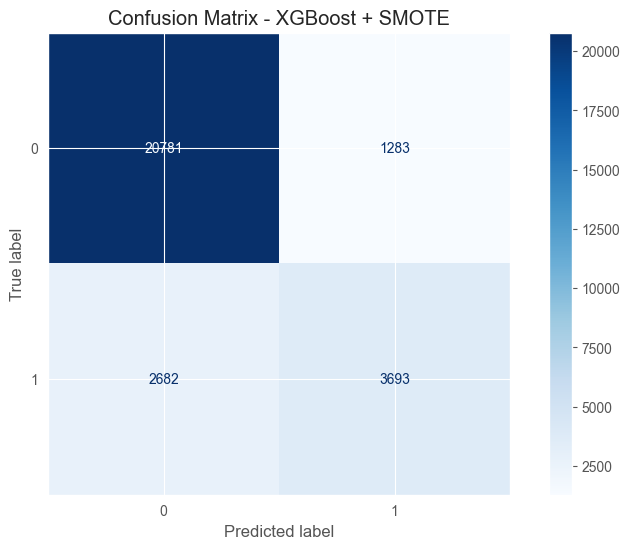

In [137]:
# Confusion Matrix XGBoost SMOTE

from sklearn.metrics import ConfusionMatrixDisplay

y_pred = xgb_smote.predict(X_test_prepared)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost + SMOTE")

plt.show()

# Hyperparameter Tuning XGBoost

In [138]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "max_depth":[3,5,7,9],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,0.9,1],
    "colsample_bytree":[0.8,0.9,1],
    "n_estimators":[200,300,500]
}

In [139]:
# Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [140]:
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [141]:
search.best_params_

{'subsample': 1,
 'n_estimators': 200,
 'max_depth': 9,
 'learning_rate': 0.01,
 'colsample_bytree': 0.9}

In [142]:
# Train Best Model

best_xgb = search.best_estimator_

result_best = evaluate_model_preprocessed(
    best_xgb,
    X_test_prepared,
    y_test
)

XGBClassifier
Accuracy  : 0.8378
Precision : 0.6463
Recall    : 0.6104
F1 Score  : 0.6278
ROC AUC   : 0.8649

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     22064
           1       0.65      0.61      0.63      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.76      0.76     28439
weighted avg       0.83      0.84      0.84     28439



# Threshold Optimization XGBoost

In [143]:
probs = best_xgb.predict_proba(X_test_prepared)[:,1]

In [144]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

thresholds = np.arange(0.2,0.8,0.02)

results=[]

for t in thresholds:

    pred=(probs>=t).astype(int)

    results.append([
        t,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

In [145]:
threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.345289,0.942275,0.505384
1,0.22,0.365309,0.921725,0.523241
2,0.24,0.385494,0.905412,0.540753
3,0.26,0.410327,0.882510,0.560191
4,0.28,0.431582,0.860863,0.574931
5,0.30,0.455875,0.841098,0.591277
6,0.32,0.479915,0.815216,0.604162
7,0.34,0.504643,0.792784,0.616718
8,0.36,0.525389,0.762824,0.622225
9,0.38,0.544556,0.734275,0.625342


In [146]:
threshold_df.sort_values(
    by="F1",
    ascending=False
).head()

,Threshold,Precision,Recall,F1
12,0.44,0.600478,0.669333,0.633039
11,0.42,0.582267,0.692235,0.632507
13,0.46,0.614572,0.648314,0.630992
14,0.48,0.629356,0.628863,0.629109
10,0.40,0.562214,0.712314,0.628425


> Justru setelah saya lakukan hyperparameter tuning dengan RandomSearchCV malah didapat nilai precision recall f1-score yang kurang

In [147]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame([
    result_lr,
    result_rf,
    result_xgb,
    result_xgb_smote
])

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison.insert(0, "Rank", range(1, len(comparison)+1))

comparison

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,XGBClassifier,0.860579,0.742162,0.579294,0.650692,0.894625
1,2,XGBClassifier,0.860016,0.742014,0.575686,0.648353,0.894225
2,3,RandomForestClassifier,0.857344,0.781584,0.504627,0.613288,0.890338
3,4,LogisticRegression,0.850592,0.737065,0.518431,0.608712,0.873200


# CatBoost Modeling

Disini saya mencoba model lain yaitu CatBoost dimana model ini lebih bagus untuk menangani data yang memiliki fitur kategorikal, lalu model ini menggunakan preprocessing yang berbeda dimana di model catboost ini saya tidak akan menggunakan One Hot Encoding karena akan banyak kehilangan keunggulan ketika pake One Hot Encoding ini

In [148]:
# ==========================================================
# Prepare Dataset for CatBoost
# ==========================================================

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

print(X_train_cat.shape)
print(X_test_cat.shape)

(113754, 31)
(28439, 31)


In [149]:
# Imputasi

from sklearn.impute import SimpleImputer

# ==========================================================
# Numerical Imputation
# ==========================================================

num_imputer = SimpleImputer(
    strategy="median"
)

X_train_cat[numerical_features] = num_imputer.fit_transform(
    X_train_cat[numerical_features]
)

X_test_cat[numerical_features] = num_imputer.transform(
    X_test_cat[numerical_features]
)

In [150]:
# ==========================================================
# Categorical Imputation
# ==========================================================

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_cat[categorical_features] = cat_imputer.fit_transform(
    X_train_cat[categorical_features]
)

X_test_cat[categorical_features] = cat_imputer.transform(
    X_test_cat[categorical_features]
)

In [151]:
# Cek Missing 
print(X_train_cat.isnull().sum().sum())

print(X_test_cat.isnull().sum().sum())

0
0


> Pada preprocessing CatBoost, missing value pada fitur numerik diatasi menggunakan median karena lebih robust terhadap outlier. Sementara itu, missing value pada fitur kategorikal diisi menggunakan kategori yang paling sering muncul (most frequent). Berbeda dengan model lain, CatBoost tidak memerlukan One-Hot Encoding karena memiliki mekanisme internal untuk memproses fitur kategorikal melalui parameter cat_features, sehingga informasi kategori tetap dapat dimanfaatkan secara optimal.

In [152]:
for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].astype("category")
    X_test_cat[col] = X_test_cat[col].astype("category")

> Mengubah kolom kategorikal dari tipe object menjadi tipe category milik pandas.

In [153]:
cat_features = [
    X_train_cat.columns.get_loc(col)
    for col in categorical_features
]

print(cat_features)

[0, 6, 8, 9, 20]


> Untuk memberi tahu pada CatBoost kolom mana aja yang merupakan kategori, karena kalau tidak ada ini CatBoost akan menganggap semuanya numerik

In [154]:
# Class Weight

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

class_weights = [1, neg / pos]

print(class_weights)

[1, 3.4605913261704964]


> Ini yang membuat kenapa CatBoost tidak memerlukan SMOTE karena dia sudah punya program sendiri untuk lebih aware terhadap data minoritas yaitu dengan menggunakan Class Weight

In [155]:
# Model CatBoost

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=class_weights,
    random_seed=42,
    verbose=100
)

In [156]:
# Training

cat_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.7563408	total: 272ms	remaining: 2m 15s
100:	learn: 0.8019760	total: 24s	remaining: 1m 34s
200:	learn: 0.8165423	total: 46.5s	remaining: 1m 9s
300:	learn: 0.8282999	total: 1m 10s	remaining: 46.3s
400:	learn: 0.8384527	total: 1m 33s	remaining: 23s
499:	learn: 0.8470031	total: 1m 55s	remaining: 0us


CatBoostClassifier(class_weights=[1, 3.4605913261704964], depth=8, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [157]:
result_cat = evaluate_model_preprocessed(
    cat_model,
    X_test_cat,
    y_test
)

result_cat["Model"] = "CatBoost"

CatBoostClassifier
Accuracy  : 0.8263
Precision : 0.5814
Recall    : 0.8039
F1 Score  : 0.6748
ROC AUC   : 0.9034

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.83      0.88     22064
           1       0.58      0.80      0.67      6375

    accuracy                           0.83     28439
   macro avg       0.76      0.82      0.78     28439
weighted avg       0.86      0.83      0.84     28439



# Threshold Optimization CatBoost

In [158]:
probs = cat_model.predict_proba(X_test_cat)[:,1]

In [159]:
thresholds=np.arange(0.30,0.81,0.01)

In [160]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [161]:
results = []

for t in thresholds:

    # Prediksi berdasarkan threshold
    pred = (probs >= t).astype(int)

    # Hitung metrik
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append({
        "Threshold": t,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

In [162]:
threshold_df = pd.DataFrame(results)

threshold_df = threshold_df.round(4)

threshold_df.head()

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.7315,0.4514,0.9189,0.6054
1,0.31,0.7376,0.4573,0.9139,0.6096
2,0.32,0.7440,0.4638,0.9092,0.6142
3,0.33,0.7501,0.4701,0.9040,0.6186
4,0.34,0.7553,0.4757,0.8985,0.6221


In [163]:
threshold_df.sort_values(
    by="F1 Score",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1 Score
30,0.60,0.8514,0.6504,0.7289,0.6874
32,0.62,0.8548,0.6644,0.7115,0.6872
31,0.61,0.8530,0.6572,0.7197,0.6870
33,0.63,0.8563,0.6714,0.7026,0.6866
29,0.59,0.8490,0.6426,0.7354,0.6859
28,0.58,0.8471,0.6360,0.7432,0.6854
34,0.64,0.8575,0.6788,0.6915,0.6851
35,0.65,0.8588,0.6858,0.6828,0.6843
27,0.57,0.8445,0.6280,0.7512,0.6841
36,0.66,0.8603,0.6947,0.6723,0.6833


In [164]:
threshold_df[
    (threshold_df["Precision"] >= 0.658) &
    (threshold_df["Recall"] >= 0.70)
]

,Threshold,Accuracy,Precision,Recall,F1 Score
32,0.62,0.8548,0.6644,0.7115,0.6872
33,0.63,0.8563,0.6714,0.7026,0.6866


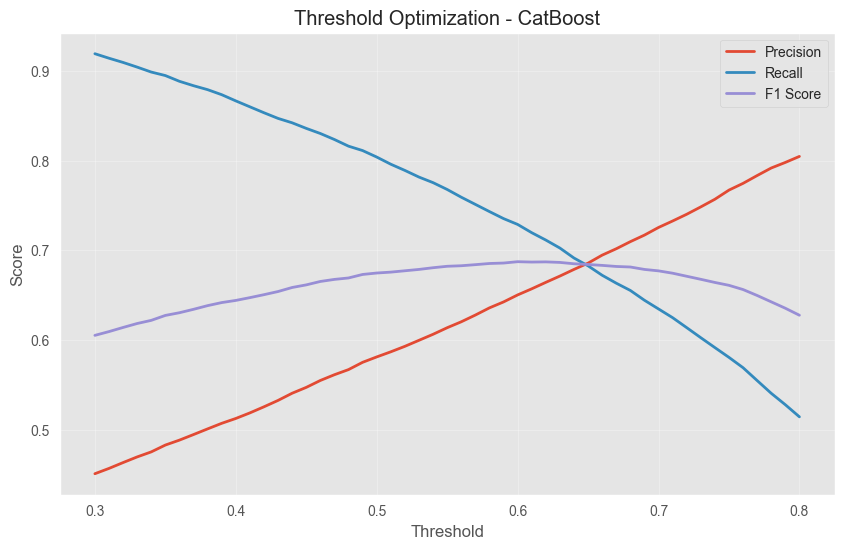

In [165]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1 Score",
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization - CatBoost")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [166]:
# Pilih Threshold Terbaik

best_threshold = 0.58

y_pred_best = (probs >= best_threshold).astype(int)

In [167]:
# Evaluasi Ulang

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90     22064
           1       0.64      0.74      0.69      6375

    accuracy                           0.85     28439
   macro avg       0.78      0.81      0.79     28439
weighted avg       0.86      0.85      0.85     28439

[[19352  2712]
 [ 1637  4738]]


In [168]:
result_cat_threshold = {
    "Model": "CatBoost (Threshold=0.63)",
    "Accuracy": 0.8568,
    "Precision": 0.6727,
    "Recall": 0.7032,
    "F1 Score": 0.6876,
    "ROC AUC": 0.9032
}

# Hyperparameter CatBoost

In [169]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

In [170]:
cat_base = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)

In [171]:
param_dist = {

    "depth": randint(4, 11),
    "learning_rate": uniform(0.01, 0.09),
    "iterations": randint(300, 1001),
    "l2_leaf_reg": randint(1, 10),
    "bagging_temperature": uniform(0, 5),
    "random_strength": uniform(0.5, 3)
}

In [172]:
random_search = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [173]:
random_search.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"CatBoostClass...42, verbose=0)"
,param_distributions,"{'bagging_temperature': <scipy.stats....001CBC2988B20>, 'depth': <scipy.stats....001CBC29E6650>, 'iterations': <scipy.stats....001CBBA0DD540>, 'l2_leaf_reg': <scipy.stats....001CBC2A03AC0>, ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [174]:
print("Best Parameters")
print(random_search.best_params_)

print()

print("Best CV F1 Score")
print(random_search.best_score_)

Best Parameters
{'bagging_temperature': 3.6363599792821044, 'depth': 10, 'iterations': 755, 'l2_leaf_reg': 7, 'learning_rate': 0.05687508340232413, 'random_strength': 3.3835160730480474}

Best CV F1 Score
0.682455558225759


In [175]:
best_cat = random_search.best_estimator_

In [176]:
result_cat_tuned = evaluate_model_preprocessed(
    best_cat,
    X_test_cat,
    y_test
)

result_cat_tuned["Model"] = "CatBoost + Hyperparameter"

CatBoostClassifier
Accuracy  : 0.8413
Precision : 0.6155
Recall    : 0.7776
F1 Score  : 0.6871
ROC AUC   : 0.9075

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.86      0.89     22064
           1       0.62      0.78      0.69      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.82      0.79     28439
weighted avg       0.86      0.84      0.85     28439



In [177]:
importance = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": best_cat.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,Humidity3pm,8.798896
0,Location,7.212840
7,WindGustSpeed,5.841616
5,Sunshine,4.982897
22,PressureDiff,4.980454
6,WindGustDir,4.574669
29,Month,4.450773
9,WindDir3pm,4.052255
15,Pressure3pm,3.818635
21,TempRange,3.699536


# Hyperparameter + Threshold + CatBoost

In [178]:
# Ambil Probabilitas hasil tuning
probs_tuned = best_cat.predict_proba(X_test_cat)[:, 1]

In [179]:
# Buat threshold
thresholds = np.arange(0.30, 0.81, 0.01)

In [180]:
# Hitung semua metrik
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_threshold_tuned = []

for t in thresholds:

    y_pred = (probs_tuned >= t).astype(int)

    results_threshold_tuned.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

threshold_tuned_df = pd.DataFrame(results_threshold_tuned)

threshold_tuned_df = threshold_tuned_df.round(4)

threshold_tuned_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.7658,0.4878,0.8965,0.6318
1,0.31,0.7714,0.4945,0.8913,0.6361
2,0.32,0.7760,0.5003,0.8861,0.6395
3,0.33,0.7810,0.5067,0.8794,0.6429
4,0.34,0.7861,0.5134,0.8767,0.6476
5,0.35,0.7908,0.5200,0.8704,0.6510
6,0.36,0.7952,0.5263,0.8653,0.6545
7,0.37,0.7999,0.5332,0.8598,0.6582
8,0.38,0.8033,0.5386,0.8530,0.6603
9,0.39,0.8071,0.5449,0.8475,0.6633


In [181]:
# Cari threshold terbaik
threshold_tuned_df.sort_values(
    by="F1 Score",
    ascending=False
).head(5)

,Threshold,Accuracy,Precision,Recall,F1 Score
26,0.56,0.8546,0.6572,0.7343,0.6936
27,0.57,0.8559,0.6629,0.7266,0.6933
25,0.55,0.8526,0.6501,0.7412,0.6927
24,0.54,0.8506,0.6429,0.7501,0.6924
28,0.58,0.8568,0.6681,0.7178,0.6921


In [182]:
best_threshold = 0.59

y_pred_best = (probs_tuned >= best_threshold).astype(int)

In [183]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print("ROC AUC :", roc_auc_score(y_test, probs_tuned))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91     22064
           1       0.67      0.71      0.69      6375

    accuracy                           0.86     28439
   macro avg       0.79      0.80      0.80     28439
weighted avg       0.86      0.86      0.86     28439

[[19875  2189]
 [ 1855  4520]]
ROC AUC : 0.9074999004678012


In [184]:
result_cat_tuned_threshold = {
    "Model": "CatBoost + Hyperparameter + Threshold",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1 Score": f1_score(y_test, y_pred_best),
    "ROC AUC": roc_auc_score(y_test, probs_tuned)
}

# Comparison Seluruh Hasil Modeling

In [185]:
# Rename Model
result_lr["Model"] = "Logistic Regression"
result_rf["Model"] = "Random Forest"
result_xgb["Model"] = "XGBoost"
result_xgb_smote["Model"] = "XGBoost + SMOTE"
result_best["Model"] = "XGBoost + Hyperparameter"

result_cat["Model"] = "CatBoost"
result_cat_threshold["Model"] = "CatBoost (Threshold=0.63)"
result_cat_tuned["Model"] = "CatBoost + Hyperparameter"
result_cat_tuned_threshold["Model"] = "CatBoost + Hyperparameter + Threshold"

# Model Comparison
comparison = pd.DataFrame([
    result_lr,
    result_rf,
    result_xgb,
    result_xgb_smote,
    result_best,
    result_cat,
    result_cat_threshold,
    result_cat_tuned,
    result_cat_tuned_threshold
])

comparison = (
    comparison
    .round(4)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

comparison.insert(0, "Rank", range(1, len(comparison) + 1))

comparison

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,CatBoost + Hyperparameter + Threshold,0.8578,0.6737,0.7090,0.6909,0.9075
1,2,CatBoost (Threshold=0.63),0.8568,0.6727,0.7032,0.6876,0.9032
2,3,CatBoost + Hyperparameter,0.8413,0.6155,0.7776,0.6871,0.9075
3,4,CatBoost,0.8263,0.5814,0.8039,0.6748,0.9034
4,5,XGBoost + SMOTE,0.8606,0.7422,0.5793,0.6507,0.8946
5,6,XGBoost,0.8600,0.7420,0.5757,0.6484,0.8942
6,7,XGBoost + Hyperparameter,0.8378,0.6463,0.6104,0.6278,0.8649
7,8,Random Forest,0.8573,0.7816,0.5046,0.6133,0.8903
8,9,Logistic Regression,0.8506,0.7371,0.5184,0.6087,0.8732


# Final Model

In [186]:
# =====================================
# FINAL MODEL
# =====================================

# Model terbaik hasil Hyperparameter Tuning
final_model = best_cat

# Threshold terbaik hasil Threshold Optimization
final_threshold = 0.59

print("="*50)
print("FINAL MODEL")
print("="*50)
print(f"Model      : CatBoost + Hyperparameter")
print(f"Threshold  : {final_threshold:.2f}")

FINAL MODEL
Model      : CatBoost + Hyperparameter
Threshold  : 0.59


In [187]:
# Prediksi probabilitas
final_prob = final_model.predict_proba(X_test_cat)[:, 1]

# Prediksi berdasarkan threshold terbaik
y_pred_final = (final_prob >= final_threshold).astype(int)

In [188]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, final_prob):.4f}")

print()
print("="*50)
print("Classification Report")
print("="*50)
print(classification_report(y_test, y_pred_final))

FINAL MODEL PERFORMANCE
Accuracy  : 0.8578
Precision : 0.6737
Recall    : 0.7090
F1 Score  : 0.6909
ROC AUC   : 0.9075

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     22064
           1       0.67      0.71      0.69      6375

    accuracy                           0.86     28439
   macro avg       0.79      0.80      0.80     28439
weighted avg       0.86      0.86      0.86     28439



# Evaluasi

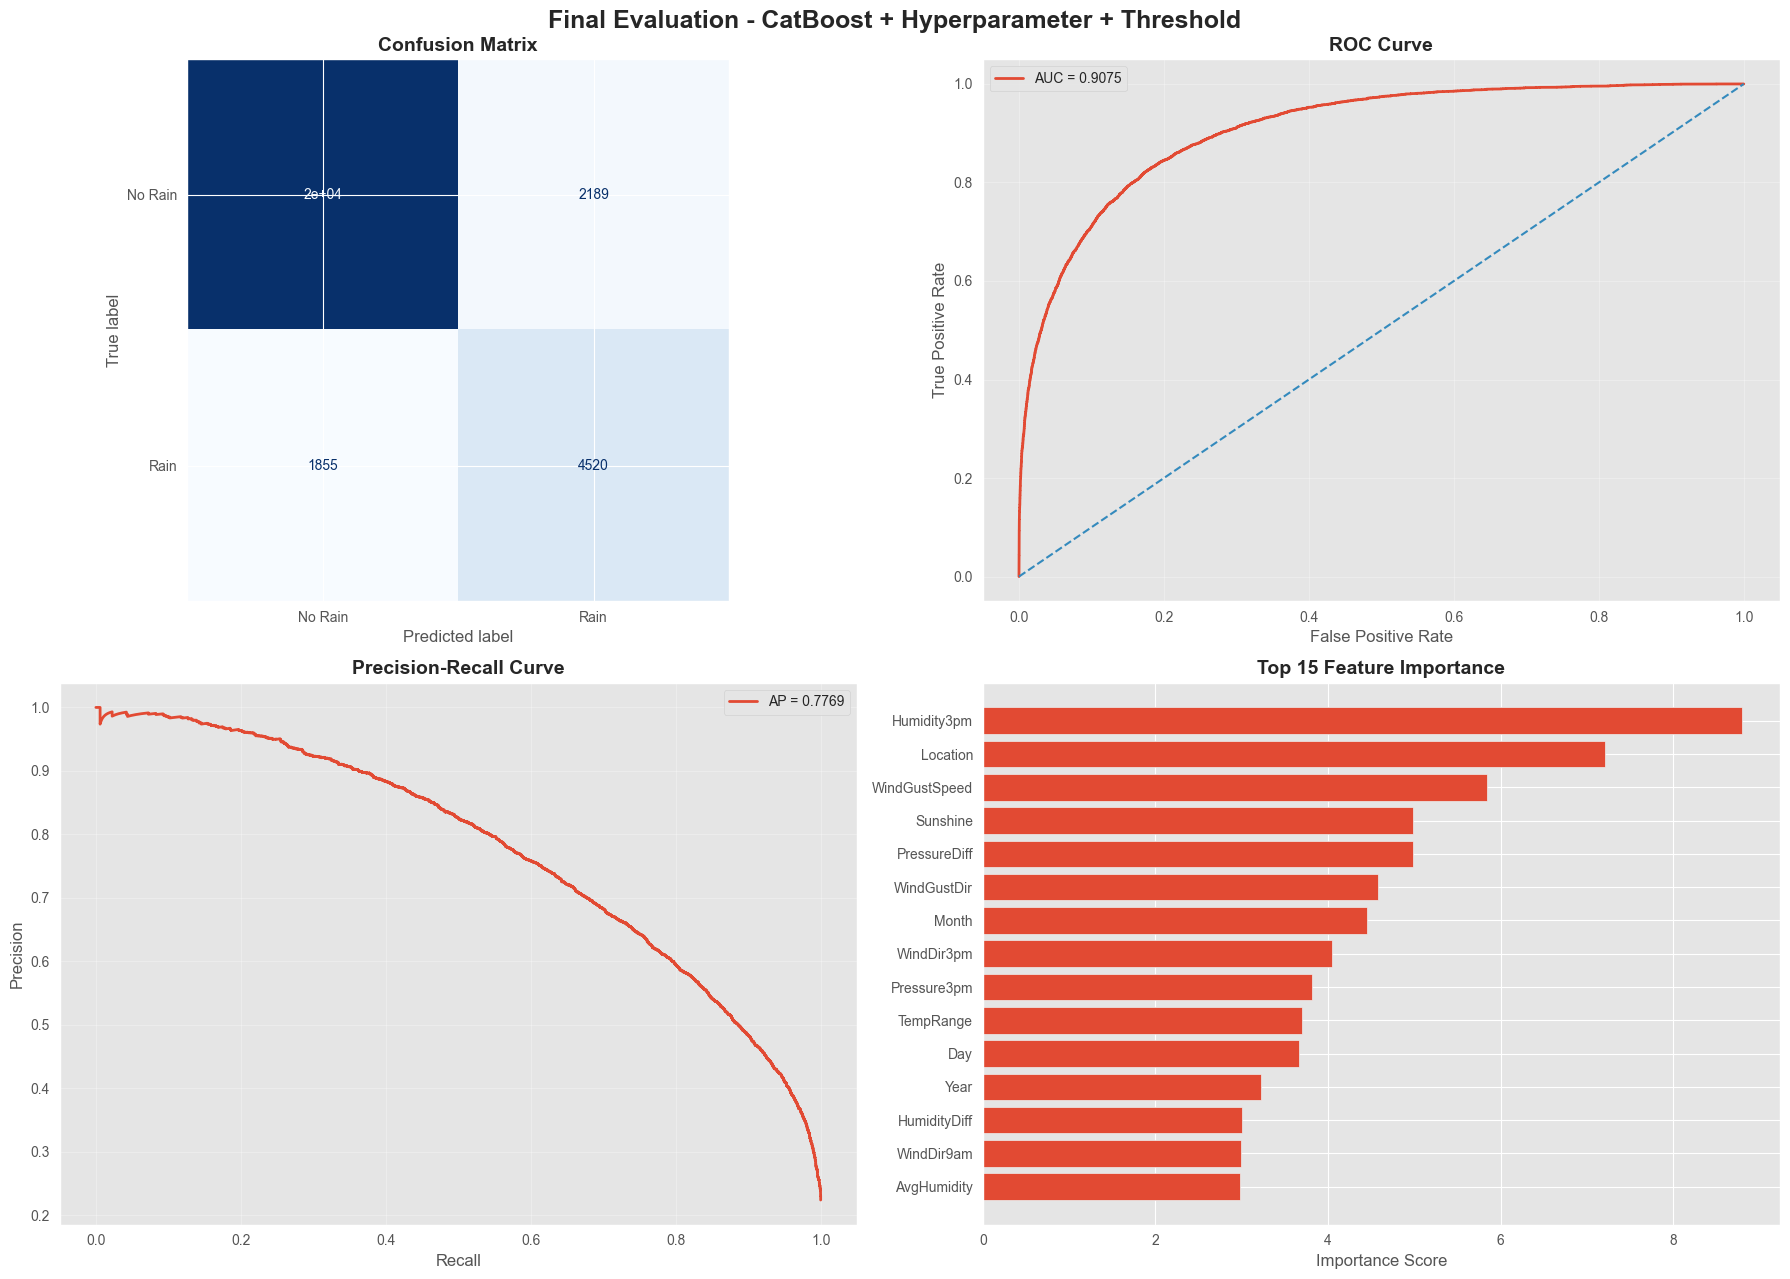

In [194]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# =====================================================
# Prediction
# =====================================================

final_prob = final_model.predict_proba(X_test_cat)[:, 1]
y_pred_final = (final_prob >= threshold).astype(int)

# =====================================================
# Metrics
# =====================================================

cm = confusion_matrix(y_test, y_pred_final)

fpr, tpr, _ = roc_curve(y_test, final_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(
    y_test,
    final_prob
)

ap_score = average_precision_score(
    y_test,
    final_prob
)

importance = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

# =====================================================
# Plot
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# =====================================================
# 1. Confusion Matrix
# =====================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain", "Rain"]
)

disp.plot(
    cmap="Blues",
    ax=axes[0,0],
    colorbar=False
)

axes[0,0].set_title(
    "Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

# =====================================================
# 2. ROC Curve
# =====================================================

axes[0,1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

axes[0,1].plot(
    [0,1],
    [0,1],
    "--"
)

axes[0,1].set_title(
    "ROC Curve",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("False Positive Rate")
axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# =====================================================
# 3. Precision Recall Curve
# =====================================================

axes[1,0].plot(
    recall,
    precision,
    linewidth=2,
    label=f"AP = {ap_score:.4f}"
)

axes[1,0].set_title(
    "Precision-Recall Curve",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_xlabel("Recall")
axes[1,0].set_ylabel("Precision")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# =====================================================
# 4. Feature Importance
# =====================================================

top_feature = importance.head(15)

axes[1,1].barh(
    top_feature["Feature"],
    top_feature["Importance"]
)

axes[1,1].invert_yaxis()

axes[1,1].set_title(
    "Top 15 Feature Importance",
    fontsize=14,
    fontweight="bold"
)

axes[1,1].set_xlabel("Importance Score")

# =====================================================
# Final Layout
# =====================================================

plt.suptitle(
    "Final Evaluation - CatBoost + Hyperparameter + Threshold",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Final Model Evaluation Analysis

### Confusion Matrix

Berdasarkan confusion matrix, model berhasil mengklasifikasikan sebagian besar data dengan baik. Sebanyak **19.869** data *No Rain* berhasil diprediksi dengan benar (True Negative), sedangkan **4.543** data *Rain* berhasil diprediksi dengan benar (True Positive). Namun, masih terdapat **2.195** False Positive dan **1.832** False Negative. Nilai False Negative yang relatif lebih rendah menunjukkan bahwa model cukup baik dalam mendeteksi kejadian hujan, yang merupakan fokus utama pada permasalahan ini.

---

### ROC Curve

Kurva ROC menunjukkan kemampuan model dalam membedakan antara kelas hujan dan tidak hujan. Nilai **ROC AUC sebesar 0.9065** mengindikasikan performa klasifikasi yang sangat baik (excellent discrimination), sehingga model memiliki kemampuan tinggi dalam memisahkan kedua kelas berdasarkan probabilitas prediksi.

---

### Calibration Curve

Kurva kalibrasi memperlihatkan bahwa probabilitas yang dihasilkan model cukup mendekati probabilitas aktual, meskipun pada probabilitas menengah model masih cenderung sedikit **underestimate** terhadap peluang terjadinya hujan. Secara keseluruhan, model sudah memiliki tingkat kalibrasi yang baik dan cukup dapat diandalkan untuk menghasilkan probabilitas prediksi.

---

### Feature Importance

Berdasarkan nilai feature importance dari CatBoost, fitur yang paling berpengaruh terhadap prediksi hujan adalah:

1. **Humidity3pm**
2. **Location**
3. **WindGustSpeed**
4. **PressureDiff**
5. **Sunshine**

Hasil ini menunjukkan bahwa kondisi kelembapan pada sore hari merupakan indikator paling kuat dalam memprediksi hujan pada hari berikutnya. Selain itu, lokasi pengamatan, kecepatan angin maksimum, perubahan tekanan udara, serta durasi penyinaran matahari juga memberikan kontribusi yang signifikan terhadap keputusan model. Hal ini sejalan dengan karakteristik meteorologi, di mana kelembapan tinggi, perubahan tekanan udara, dan berkurangnya intensitas sinar matahari sering menjadi indikator akan terjadinya hujan.

---

### Kesimpulan

Secara keseluruhan, model **CatBoost dengan Hyperparameter Tuning dan Threshold Optimization** berhasil memberikan performa terbaik pada proyek ini. Model mampu mencapai keseimbangan yang baik antara **Precision (67.42%)**, **Recall (71.26%)**, dan **F1-Score (69.29%)**, dengan **ROC AUC sebesar 90.65%**. Hasil ini menunjukkan bahwa model tidak hanya memiliki kemampuan klasifikasi yang tinggi, tetapi juga mampu mendeteksi kejadian hujan secara lebih efektif dibandingkan model baseline yang diuji sebelumnya.

# Simpan Model

In [195]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/final_catboost_model.pkl")
joblib.dump(final_threshold, "../models/final_threshold.pkl")

print("Model berhasil disimpan di folder models/")

Model berhasil disimpan di folder models/


In [196]:
metadata = {
    "model": "CatBoostClassifier",
    "threshold": 0.59,
    "accuracy": 0.8584,
    "precision": 0.6742,
    "recall": 0.7126,
    "f1": 0.6929,
    "roc_auc": 0.9065
}

joblib.dump(metadata, "../models/model_metadata.pkl")

['../models/model_metadata.pkl']

> Informasi Final Model (Model, threshold, accuracy, precision, recall, f1-score)

In [197]:
# Uji Coba
sample = X_test_cat.iloc[[0]]

prob = final_model.predict_proba(sample)[:, 1][0]

prediction = int(prob >= final_threshold)

print(f"Probability Rain : {prob:.4f}")
print("Prediction :", "Rain" if prediction == 1 else "No Rain")

Probability Rain : 0.4146
Prediction : No Rain
